# CLIP_ViT_Large_Task22.API.ipynb

Run from repo root: `CLIP_ViT_Large_Task22/`.

In [1]:
from pathlib import Path
REPO_ROOT = Path('.').resolve()
print('Repo root:', REPO_ROOT)

from CLIP_ViT_Large_Task22_utils import (
    predict_sentiment_from_raw
)
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

Repo root: /Users/pgutti/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask22_Fall2025_CLIP-ViT-Large-Multimodal_Sentiment_Analysis_on_Social_Media_Posts


/Users/pgutti/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


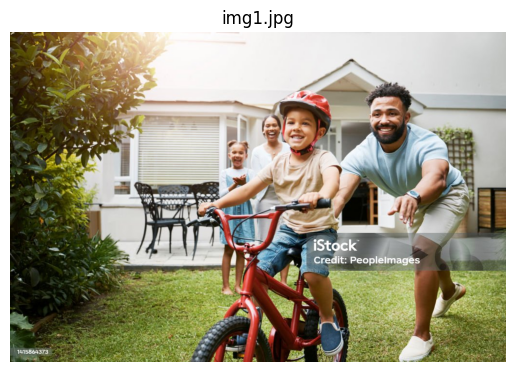

/Users/pgutti/miniconda3/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


TEXT: What a beautiful day!
TRUE: positive
PRED: positive
PROBS: {'negative': 0.12914595007896423, 'neutral': 0.04729889705777168, 'positive': 0.8235551714897156}
--------------------------------------------------------------------------------


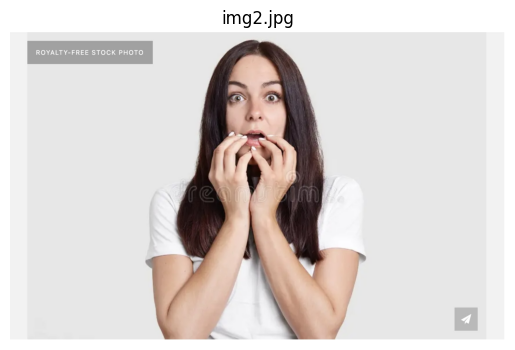

TEXT: This is terrible.
TRUE: negative
PRED: neutral
PROBS: {'negative': 0.17557182908058167, 'neutral': 0.7108991742134094, 'positive': 0.1135290116071701}
--------------------------------------------------------------------------------


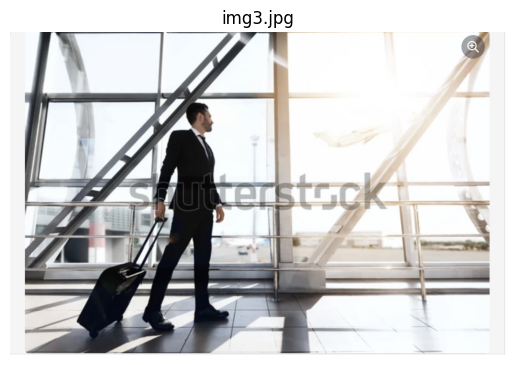

TEXT: reached airport.
TRUE: neutral
PRED: positive
PROBS: {'negative': 0.13213317096233368, 'neutral': 0.29501959681510925, 'positive': 0.5728471875190735}
--------------------------------------------------------------------------------


In [2]:
samples = [
    {
        "img_path": "data/raw/sample_infer_img/img1.jpg",
        "text": "What a beautiful day!",
        "true_label": "positive",
    },
    {
        "img_path": "data/raw/sample_infer_img/img2.jpg",
        "text": "This is terrible.",
        "true_label": "negative",
    },
    {
       
        "img_path": "data/raw/sample_infer_img/img3.jpg",
        "text": "reached airport.",
        "true_label": "neutral",
    },
]

for s in samples:
    # show image
    img_path = Path(s["img_path"])
    img = Image.open(img_path).convert("RGB")
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)
    plt.show()

    # predict (this calls utils -> embedder -> model internally)
    res = predict_sentiment_from_raw(
        img_path=img_path,     
        text=s["text"],
        device="auto",
        embedder=None,
        model_path="./artifacts/model/two_tower_v2_best.pt",         
    )

    #  print results 
    print("TEXT:", s["text"])
    print("TRUE:", s["true_label"])
    print("PRED:", res.get("pred_label"))
    print("PROBS:", res.get("probs"))

    
    if res.get("image_error") is not None:
        print("IMAGE_EMBED_ERROR:", res["image_error"])

    print("-" * 80)